# Aula 6 — Montando a CNN do artigo

**Objetivo:** reproduzir em código Keras, camada por camada, a arquitetura exata descrita na Tabela 3 do artigo original.

## O que foi feito
- Criação de um novo notebook (`02_construcao_modelo.ipynb`), separando construção/treinamento do modelo da exploração de dados.
- Recriação dos datasets de treino e teste a partir da pasta `dataset_unificado/` já existente (sem repetir a organização da Aula 3).
- Construção de um modelo `Sequential`, camada por camada:
  - `Rescaling(1./255)` — normalização embutida no próprio modelo (não usamos mais `.map()` externo).
  - 5 blocos de `Conv2D` (16, 32, 64, 128, 256 filtros, kernel 3x3, ativação ReLU, padding "same") + `MaxPooling2D` (2x2) cada.
  - `Dropout(0.2)` — desliga 20% dos neurônios aleatoriamente durante o treino, para reduzir overfitting.
  - `Flatten()` — achata o volume 9x9x256 em um vetor de 20736 números.
  - `Dense(128, activation='relu')` e `Dense(4, activation='softmax')` — camadas finais de decisão.
- Verificação com `modelo.summary()`: arquitetura bateu exatamente com a Tabela 3 do artigo (mesmos shapes e quantidade de parâmetros por camada). Total: 3.047.460 parâmetros treináveis (~11.63 MB).

## Conceitos-chave
- **Sequential**: forma do Keras de empilhar camadas em uma pilha linear, na ordem de execução.
- **padding="same"**: adiciona borda de zeros à imagem antes da convolução, mantendo o tamanho espacial de saída igual ao de entrada.
- **activation='relu' embutido na camada**: forma compacta de aplicar convolução + ReLU em uma única linha, sem precisar de uma camada separada.
- **Dropout**: desliga neurônios aleatoriamente durante o treino (só durante o treino, não na inferência) para evitar que a rede dependa demais de neurônios específicos — técnica contra overfitting.
- **softmax**: transforma os números finais de saída em valores que somam 100%, interpretáveis como probabilidade de cada classe.
- **`.summary()`**: método que lista todas as camadas do modelo com seus shapes e parâmetros, útil para validar a arquitetura contra uma especificação.

## Observação / erro corrigido
Uma célula foi executada duas vezes por engano, duplicando os dois primeiros blocos convolucionais. Corrigido reiniciando o Kernel e reexecutando todas as células em ordem (`Kernel → Restart Kernel and Run All Cells`) — lição prática sobre como `Sequential.add()` sempre soma camadas novas, sem verificar duplicação.

## Parâmetro assumido (não especificado no artigo)
O artigo não especifica o tamanho do kernel de convolução nem a taxa exata de dropout usada. Assumimos `kernel_size=(3,3)` (padrão mais comum na área) e `dropout=0.2` (valor razoável, dentro do que o texto do artigo descreve como processo de tentativa e erro).

In [1]:
from tensorflow import keras
from tensorflow.keras import layers

dataset_treino = keras.utils.image_dataset_from_directory(
    "dataset_unificado",
    image_size=(300, 300),
    batch_size=32,
    validation_split=0.2,
    subset="training",
    seed=42
)

dataset_teste = keras.utils.image_dataset_from_directory(
    "dataset_unificado",
    image_size=(300, 300),
    batch_size=32,
    validation_split=0.2,
    subset="validation",
    seed=42
)

I0000 00:00:1789265295.872672    3789 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1789265295.924907    3789 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1789265297.276446    3789 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Found 18781 files belonging to 4 classes.
Using 15025 files for training.


E0000 00:00:1789265298.574769    3789 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Found 18781 files belonging to 4 classes.
Using 3756 files for validation.


In [2]:
modelo = keras.Sequential()

modelo.add(layers.Rescaling(1./255, input_shape=(300, 300, 3)))

/home/gustavo/Documentos/GitHub/projetoInteligenciaArtificial/venv/lib/python3.13/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [3]:
# Bloco 1
modelo.add(layers.Conv2D(filters=16, kernel_size=(3, 3), activation='relu', padding='same'))
modelo.add(layers.MaxPooling2D(pool_size=(2, 2)))


In [4]:
# Bloco 2
modelo.add(layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu', padding='same'))
modelo.add(layers.MaxPooling2D(pool_size=(2, 2)))

In [5]:
# Bloco 3
modelo.add(layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu', padding='same'))
modelo.add(layers.MaxPooling2D(pool_size=(2, 2)))

# Bloco 4
modelo.add(layers.Conv2D(filters=128, kernel_size=(3, 3), activation='relu', padding='same'))
modelo.add(layers.MaxPooling2D(pool_size=(2, 2)))

# Bloco 5
modelo.add(layers.Conv2D(filters=256, kernel_size=(3, 3), activation='relu', padding='same'))
modelo.add(layers.MaxPooling2D(pool_size=(2, 2)))

In [6]:
modelo.add(layers.Dropout(0.2))
modelo.add(layers.Flatten())
modelo.add(layers.Dense(128, activation='relu'))
modelo.add(layers.Dense(4, activation='softmax'))

In [7]:
modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 300, 300, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 150, 150, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 150, 150, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,654,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,047,460 (11.63 MB)

 Trainable params: 3,047,460 (11.63 MB)

 Non-trainable params: 0 (0.00 B)

# Aula 7 — Compilando e treinando

**Objetivo:** configurar o processo de aprendizado do modelo (otimizador e função de perda) e executar o treinamento completo de 30 épocas, replicando a metodologia do artigo, com salvamento automático do melhor resultado.

## O que foi feito
- Compilação do modelo com `optimizer='adam'`, `loss='sparse_categorical_crossentropy'` e `metrics=['accuracy']`.
- Teste inicial com 2 épocas para estimar tempo de execução em CPU: ~8,75 minutos/época, projetando ~4h22min para as 30 épocas completas.
- Configuração de um `ModelCheckpoint` (`monitor="val_accuracy"`, `save_best_only=True`), salvando em disco (`melhor_modelo.keras`) apenas quando a acurácia de validação melhora — proteção contra perda de progresso e contra ficar com a última época (não necessariamente a melhor) ao final do treino.
- Execução do treinamento completo: 30 épocas, ~264 minutos (4h24min) em CPU.
- Carregamento do melhor modelo salvo em disco (`keras.models.load_model`) para uso nas próximas etapas, em vez da variável em memória (que ficou com os pesos da última época, não da melhor).

## Resultado do treinamento
- **Melhor checkpoint: época 19**, com `val_accuracy = 98,32%` e `val_loss = 0,0865`.
- A partir da época 19, sinal claro de **overfitting**: `accuracy` de treino continuou subindo até ~99,8%, enquanto `val_accuracy` oscilou/piorou e `val_loss` subiu (de 0,0865 para ~0,15 na época 30) — a rede passou a "decorar" o treino em vez de generalizar.
- Resultado final (melhor época) próximo ao do artigo: 98,32% vs 98,72% reportado no artigo — diferença plausível, considerando que o dataset usado tem 700 (não 3500) imagens de Tuberculosis, conforme divergência já documentada na Aula 3.

## Conceitos-chave
- **Época**: uma passada completa por todos os lotes do dataset de treino.
- **Loss (função de perda)**: mede o quão erradas as previsões estão, considerando também a confiança da previsão (diferente da accuracy, que só considera acerto/erro binário). É o valor que o otimizador usa para ajustar os pesos.
- **Otimizador (Adam)**: algoritmo que ajusta os parâmetros da rede a cada lote, na direção que reduz o loss.
- **`.compile()` vs `.fit()`**: compile configura as regras do treinamento (loss, otimizador, métricas) sem treinar nada; fit executa o treinamento de fato.
- **Checkpoint (`ModelCheckpoint`)**: callback que salva o modelo em disco durante o treinamento, permitindo preservar a melhor versão (segundo uma métrica escolhida) mesmo que épocas posteriores piorem, e evitando perda total de progresso em caso de interrupção.
- **RAM vs disco**: o modelo em treinamento existe apenas na memória RAM até ser salvo; um arquivo `.keras` salvo em disco persiste mesmo após fechar o Jupyter ou reiniciar o Kernel.
- **Overfitting (observado na prática)**: quando a acurácia de treino continua melhorando mas a de validação estagna ou piora — sinal de que o modelo está memorizando os dados de treino em vez de aprender padrões generalizáveis.

## Observações / limitações levantadas (para a apresentação final)
- Métrica de monitoramento do checkpoint (`val_accuracy`) pode ser subótima em dataset desbalanceado — métricas como F1-score por classe ou `val_loss` seriam mais robustas nesse cenário. Fica como ponto de discussão metodológica.
- Treinamento realizado inteiramente em CPU (sem GPU/CUDA disponível), tempo total de ~4h24min para 30 épocas.

In [8]:
modelo.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
import time

inicio = time.time()

historico_teste = modelo.fit(
    dataset_treino,
    validation_data=dataset_teste,
    epochs=2
)

fim = time.time()
print(f"\nTempo total para 2 épocas: {(fim - inicio)/60:.1f} minutos")

Epoch 1/2


/home/gustavo/Documentos/GitHub/projetoInteligenciaArtificial/venv/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
W0000 00:00:1789265811.889446    3912 cpu_allocator_impl.cc:82] Allocation of 184320000 exceeds 10% of free system memory.
W0000 00:00:1789265812.017969    3912 cpu_allocator_impl.cc:82] Allocation of 92160000 exceeds 10% of free system memory.
W0000 00:00:1789265812.471057    3912 cpu_allocator_impl.cc:82] Allocation of 92160000 exceeds 10% of free system memory.
W0000 00:00:1789265812.771125    3918 cpu_allocator_impl.cc:82] Allocation of 92160000 exceeds 10% of free system memory.
W0000 00:00:1789265812.771202    3918 cpu_allocator_impl.cc:82] Allocation of 184320000 exceeds 10% of free system memory.


470/470 ━━━━━━━━━━━━━━━━━━━━ 534s 1s/step - accuracy: 0.8741 - loss: 0.3352 - val_accuracy: 0.9252 - val_loss: 0.1944
Epoch 2/2
470/470 ━━━━━━━━━━━━━━━━━━━━ 514s 1s/step - accuracy: 0.9408 - loss: 0.1618 - val_accuracy: 0.9430 - val_loss: 0.1572

Tempo total para 2 épocas: 17.5 minutos


In [10]:
checkpoint = keras.callbacks.ModelCheckpoint(
    filepath="melhor_modelo.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

In [11]:
import time

inicio = time.time()

historico = modelo.fit(
    dataset_treino,
    validation_data=dataset_teste,
    epochs=30,
    callbacks=[checkpoint]
)

fim = time.time()
print(f"\nTempo total para 30 épocas: {(fim - inicio)/60:.1f} minutos")

Epoch 1/30
470/470 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9584 - loss: 0.1175
Epoch 1: val_accuracy improved from None to 0.95740, saving model to melhor_modelo.keras

Epoch 1: finished saving model to melhor_modelo.keras
470/470 ━━━━━━━━━━━━━━━━━━━━ 518s 1s/step - accuracy: 0.9584 - loss: 0.1175 - val_accuracy: 0.9574 - val_loss: 0.1243
Epoch 2/30
470/470 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9697 - loss: 0.0874
Epoch 2: val_accuracy improved from 0.95740 to 0.96592, saving model to melhor_modelo.keras

Epoch 2: finished saving model to melhor_modelo.keras
470/470 ━━━━━━━━━━━━━━━━━━━━ 517s 1s/step - accuracy: 0.9697 - loss: 0.0874 - val_accuracy: 0.9659 - val_loss: 0.0937
Epoch 3/30
470/470 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9770 - loss: 0.0660
Epoch 3: val_accuracy did not improve from 0.96592
470/470 ━━━━━━━━━━━━━━━━━━━━ 520s 1s/step - accuracy: 0.9770 - loss: 0.0660 - val_accuracy: 0.9513 - val_loss: 0.1925
Epoch 4/30
470/470 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/ste

In [3]:
from tensorflow import keras
from tensorflow.keras import layers

dataset_treino = keras.utils.image_dataset_from_directory(
    "dataset_unificado",
    image_size=(300, 300),
    batch_size=32,
    validation_split=0.2,
    subset="training",
    seed=42
)

dataset_teste = keras.utils.image_dataset_from_directory(
    "dataset_unificado",
    image_size=(300, 300),
    batch_size=32,
    validation_split=0.2,
    subset="validation",
    seed=42
)

I0000 00:00:1789313405.546784     941 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1789313405.598911     941 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1789313406.926395     941 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Found 18781 files belonging to 4 classes.
Using 15025 files for training.


E0000 00:00:1789313408.259031     941 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Found 18781 files belonging to 4 classes.
Using 3756 files for validation.


In [4]:
melhor_modelo = keras.models.load_model("melhor_modelo.keras")

In [5]:
import numpy as np

rotulos_verdadeiros = []
previsoes = []

for lote_imagens, lote_rotulos in dataset_teste:
    saida_modelo = melhor_modelo.predict(lote_imagens, verbose=0)
    previsoes_lote = np.argmax(saida_modelo, axis=1)
    
    rotulos_verdadeiros.extend(lote_rotulos.numpy())
    previsoes.extend(previsoes_lote)

rotulos_verdadeiros = np.array(rotulos_verdadeiros)
previsoes = np.array(previsoes)

print("Total de imagens avaliadas:", len(rotulos_verdadeiros))

Total de imagens avaliadas: 3756


In [6]:
from sklearn.metrics import classification_report

nomes_classes = ['COVID-19', 'Normal', 'Pneumonia', 'Tuberculosis']

relatorio = classification_report(
    rotulos_verdadeiros, 
    previsoes, 
    target_names=nomes_classes
)

print(relatorio)

              precision    recall  f1-score   support

    COVID-19       0.95      0.97      0.96       702
      Normal       0.99      0.99      0.99      2039
   Pneumonia       1.00      0.99      1.00       870
Tuberculosis       0.96      0.94      0.95       145

    accuracy                           0.98      3756
   macro avg       0.97      0.97      0.97      3756
weighted avg       0.98      0.98      0.98      3756



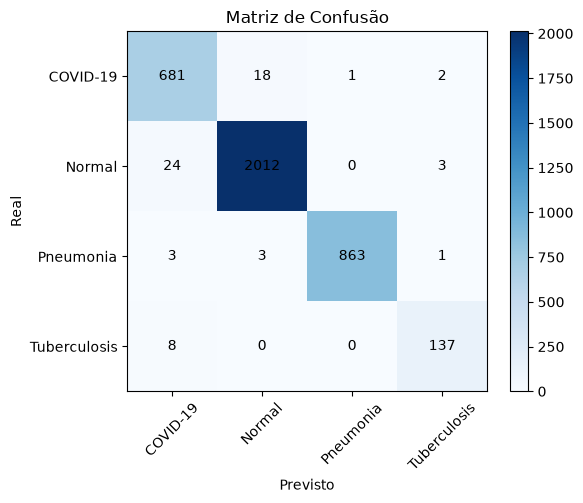

In [11]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

matriz = confusion_matrix(rotulos_verdadeiros, previsoes)

plt.figure(figsize=(6, 5))
plt.imshow(matriz, cmap='Blues')
plt.colorbar()
plt.xticks(range(4), nomes_classes, rotation=45)
plt.yticks(range(4), nomes_classes)
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão')

for i in range(4):
    for j in range(4):
        plt.text(j, i, matriz[i, j], ha='center', va='center')

plt.tight_layout()
plt.show()